In [ ]:
# Import Libraries


# Data Handling


import pandas as pd
import numpy as np

In [2]:
# Visualization


import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Machine Learning


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [4]:
# Models


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [5]:
# Evaluation


from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
# Hyperparameter Tuning



from sklearn.model_selection import GridSearchCV

In [7]:
# Ignore warnings


import warnings
warnings.filterwarnings("ignore")

In [9]:
# Load Dataset


df = pd.read_csv(
    "Chicago_Crimes_2001_to_2004.csv",
    engine="python",
    on_bad_lines="skip"
)

# Display first 5 rows
print(df.head())

# Shape of dataset
print("Rows and Columns:", df.shape)

   Unnamed: 0       ID Case Number                    Date  \
0         879  4786321    HM399414  01/01/2004 12:01:00 AM   
1        2544  4676906    HM278933  03/01/2003 12:00:00 AM   
2        2919  4789749    HM402220  06/20/2004 11:00:00 AM   
3        2927  4789765    HM402058  12/30/2004 08:00:00 PM   
4        3302  4677901    HM275615  05/01/2003 01:00:00 AM   

                 Block  IUCR                Primary Type  \
0    082XX S COLES AVE  0840                       THEFT   
1      004XX W 42ND PL  2825               OTHER OFFENSE   
2  025XX N KIMBALL AVE  1752  OFFENSE INVOLVING CHILDREN   
3   045XX W MONTANA ST  0840                       THEFT   
4   111XX S NORMAL AVE  0841                       THEFT   

                      Description Location Description  Arrest  ...  Ward  \
0   FINANCIAL ID THEFT: OVER $300            RESIDENCE   False  ...   7.0   
1         HARASSMENT BY TELEPHONE            RESIDENCE   False  ...  11.0   
2   AGG CRIM SEX ABUSE FAM MEMBER  

In [10]:
# Dataset information


print(df.info())

# Statistical summary


print(df.describe())

# Column names


print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1923515 entries, 0 to 1923514
Data columns (total 23 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0            int64  
 1   ID                    int64  
 2   Case Number           object 
 3   Date                  object 
 4   Block                 object 
 5   IUCR                  object 
 6   Primary Type          object 
 7   Description           object 
 8   Location Description  object 
 9   Arrest                bool   
 10  Domestic              bool   
 11  Beat                  int64  
 12  District              float64
 13  Ward                  float64
 14  Community Area        float64
 15  FBI Code              object 
 16  X Coordinate          float64
 17  Y Coordinate          object 
 18  Year                  float64
 19  Updated On            object 
 20  Latitude              object 
 21  Longitude             float64
 22  Location              object 
dtypes: bool

In [11]:
# Missing values count


missing_values = df.isnull().sum()

print(missing_values.sort_values(ascending=False))

Community Area          700247
Ward                    700132
Location                 30692
Longitude                30692
Latitude                 30691
X Coordinate             30691
Y Coordinate             30691
Location Description        16
District                     2
Block                        0
IUCR                         0
Case Number                  0
ID                           0
Unnamed: 0                   0
Date                         0
Primary Type                 0
Description                  0
Arrest                       0
Domestic                     0
Beat                         0
FBI Code                     0
Year                         0
Updated On                   0
dtype: int64


In [12]:
# Remove Unnecessary Columns


drop_cols = [
    'Unnamed: 0',
    'ID',
    'Case Number',
    'Updated On',
    'Location',
    'X Coordinate',
    'Y Coordinate'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [13]:
# Handle Missing Values


# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Fill numerical missing values
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [14]:
# Convert Date Variable


df['Date'] = pd.to_datetime(df['Date'])

# Extract useful features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year
df['Hour'] = df['Date'].dt.hour

# Remove original date column
df.drop('Date', axis=1, inplace=True)

In [15]:
# Define Target Variable


# Target variable
target = 'Primary Type'

# Encode target
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

In [16]:
# Sampling


df_sample = df.sample(
    n=50000,
    random_state=42
)

print(df_sample.shape)

(50000, 18)


In [18]:
# Encode Categorical Variables


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [19]:
X = df_sample.drop('Primary Type', axis=1)
y = df_sample['Primary Type']

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify column types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

In [21]:
# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

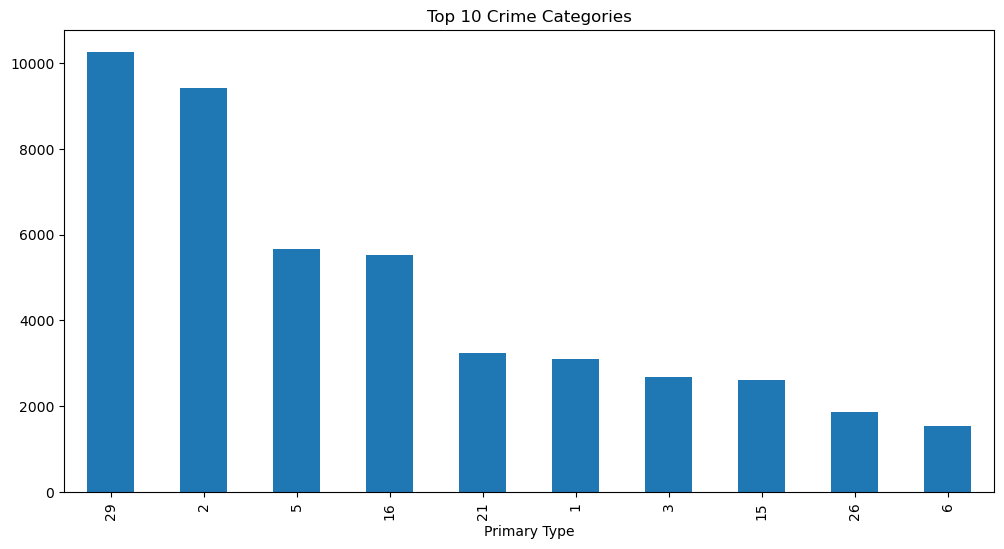

In [22]:
# Exploratory Data Analysis (EDA)

# Crime Type Distribution


plt.figure(figsize=(12,6))

df_sample['Primary Type'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Crime Categories")
plt.show()

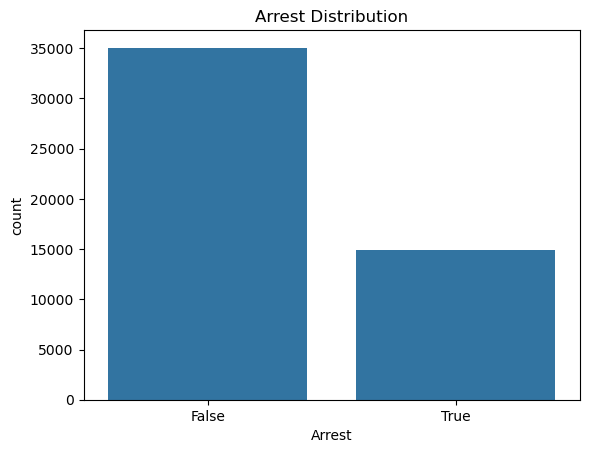

In [23]:
# Arrest Distribution


sns.countplot(
    x='Arrest',
    data=df_sample
)

plt.title("Arrest Distribution")
plt.show()

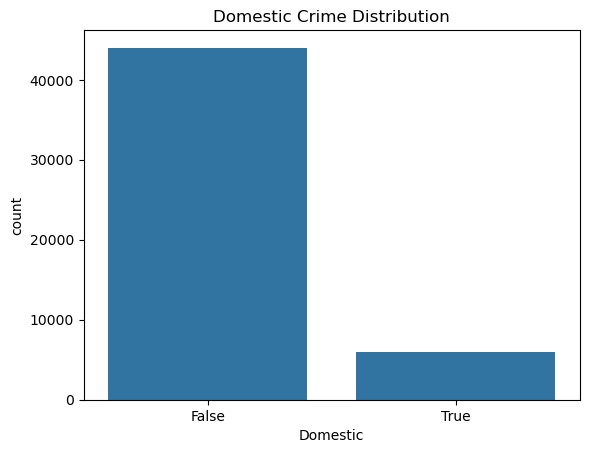

In [24]:
# Domestic Crime Distribution


sns.countplot(
    x='Domestic',
    data=df_sample
)

plt.title("Domestic Crime Distribution")
plt.show()

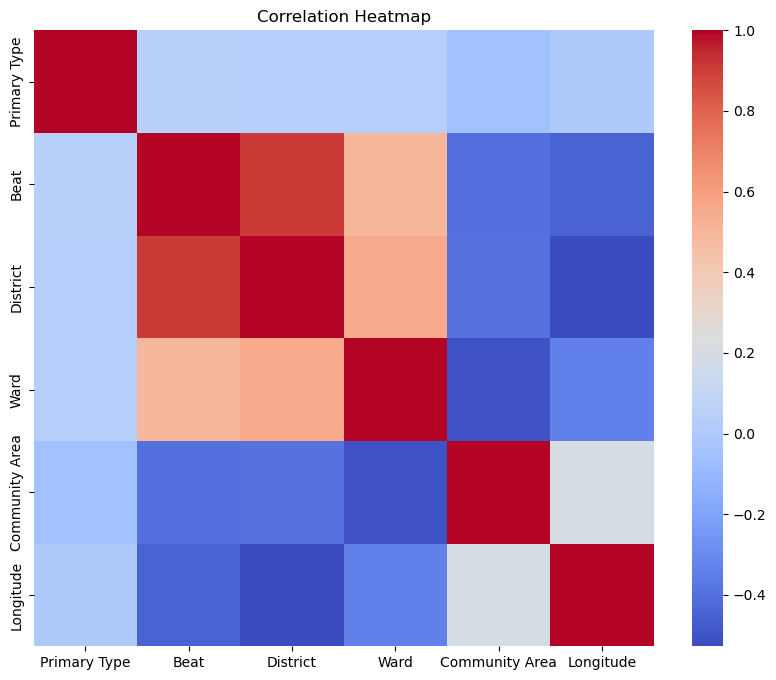

In [25]:
# Correlation Heatmap


numeric_df = df_sample.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Model 1 - Logistic Regression


lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00       635
           2       1.00      1.00      1.00      1896
           3       1.00      1.00      1.00       515
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00      1129
           6       1.00      1.00      1.00       280
           7       1.00      1.00      1.00       293
           9       1.00      1.00      1.00        19
          10       1.00      0.95      0.98        21
          11       1.00      0.91      0.95        11
          12       1.00      0.82      0.90        11
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00        28
          15       1.00      1.00      1.00       538
          16       1.00      1.00      1.00      1106
          19       1.00      0.99      0.99        68
          

**Accuracy (0.9995)**
The model correctly predicted the class for 99.95% of the 10,000 test samples, making only 5 total mistakes.

**Precision (1.00 for almost all classes)**
Out of all the times the model predicted a specific class, it was correct 100% of the time, resulting in almost zero false positives.

**Recall (1.00 for most classes, lower for 10, 11, 12)**
The model successfully found all actual instances for most classes. For class 12, it only found 82% of the actual instances, missing 2 out of the 11 total available samples.

**F1-Score (1.00 for most classes)**
The balance between precision and recall is near-perfect across the dataset, except for slight drops in classes 10 (0.98), 11 (0.95), and 12 (0.90).

**Support (ranging from 1 to 2,057)**
The dataset has extreme class imbalance. Some categories have thousands of examples (like class 29 with 2,057), while others have very few (like class 28 with only 1).

In [27]:
# Model 2 - Decision Tree


dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(
    y_test,
    y_pred_dt
))

Accuracy: 0.9996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00       635
           2       1.00      1.00      1.00      1896
           3       1.00      1.00      1.00       515
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00      1129
           6       1.00      1.00      1.00       280
           7       1.00      1.00      1.00       293
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        21
          11       1.00      0.91      0.95        11
          12       1.00      0.82      0.90        11
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00        28
          15       1.00      1.00      1.00       538
          16       1.00      1.00      1.00      1106
          19       1.00      1.00      1.00        68
          

**Accuracy (0.9996)**
The model correctly predicted the class for 99.96% of the 10,000 test samples, making only 4 total mistakes.

**Precision (1.00 for almost all classes, 0.98 for class 24)**
The model was correct 100% of the time it predicted a specific class, except for class 24, where it made a slight error by misclassifying another sample into this category.

**Recall (1.00 for most classes, lower for 11 and 12)**
The model successfully found all actual instances for almost every class. It missed 1 out of 11 samples for class 11 (91% found) and missed 2 out of 11 samples for class 12 (82% found).

**F1-Score (1.00 for most classes)**
The balance between precision and recall remains near-perfect, with minor drops only occurring in classes 11 (0.95), 12 (0.90), and 24 (0.99).

**Support (ranging from 1 to 2,057)**
The dataset shows extreme class imbalance, where some categories contain thousands of examples (class 29 has 2,057) while others contain nearly none (class 28 has 1).

In [28]:
# Model 3 - Random Forest


rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00       635
           2       1.00      1.00      1.00      1896
           3       1.00      1.00      1.00       515
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00      1129
           6       1.00      1.00      1.00       280
           7       1.00      1.00      1.00       293
           9       0.95      1.00      0.97        19
          10       1.00      1.00      1.00        21
          11       1.00      0.73      0.84        11
          12       1.00      0.82      0.90        11
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00        28
          15       1.00      1.00      1.00       538
          16       1.00      1.00      1.00      1106
          19       1.00      0.97      0.99        68
          2

**Accuracy (0.999)**
The model correctly predicted the class for 99.90% of the 10,000 test samples, making exactly 10 total mistakes.

**Precision (1.00 for most classes, lower for 9 and 21)**
The model was correct 100% of the time it predicted a specific class, with slight exceptions for class 9 (95% correct) and class 21 (99% correct), meaning it accidentally included a few incorrect samples in those categories.

**Recall (1.00 for most classes, lower for 11, 12, 19, 24)**
The model successfully found all actual instances for most classes. However, it missed 3 out of 11 samples for class 11 (73% found), 2 out of 11 samples for class 12 (82% found), 2 out of 68 samples for class 19 (97% found), and 1 out of 53 samples for class 24 (98% found).

**F1-Score (1.00 for most classes)**
The balance between precision and recall remains very high overall, with the lowest performance occurring in class 11 (0.84) and class 12 (0.90).

**Support (ranging from 1 to 2,057)**
The dataset shows extreme class imbalance, where some categories contain thousands of examples (class 29 has 2,057) while others contain nearly none (class 28 has 1).

In [30]:
# Model 4 - Gaussian Naive Bayes


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import ComplementNB  # Better for sparse/categorical data
from sklearn.metrics import accuracy_score, classification_report

# 1. Use OneHotEncoder to create a memory-efficient sparse matrix
encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

# 2. Split the sparse matrix (train_test_split handles this perfectly)
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

# 3. Use ComplementNB (or MultinomialNB), which natively accepts sparse matrices
nb = ComplementNB()
nb.fit(X_train_nb, y_train_nb)

# 4. Predict and Evaluate
y_pred_nb = nb.predict(X_test_nb)

print("Accuracy:", accuracy_score(y_test_nb, y_pred_nb))
print(classification_report(y_test_nb, y_pred_nb))

Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00       635
           2       1.00      1.00      1.00      1896
           3       1.00      1.00      1.00       515
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00      1129
           6       1.00      1.00      1.00       280
           7       1.00      1.00      1.00       293
           9       0.90      1.00      0.95        19
          10       1.00      1.00      1.00        21
          11       1.00      1.00      1.00        11
          12       1.00      0.82      0.90        11
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00        28
          15       1.00      1.00      1.00       538
          16       1.00      1.00      1.00      1106
          19       1.00      1.00      1.00        68
          

**Accuracy (0.9995)**
The model correctly predicted the class for 99.95% of the 10,000 test samples, making exactly 5 total mistakes.

**Precision (1.00 for most classes, lower for 9 and 28)**
The model was correct 100% of the time it predicted a specific class, with exceptions for class 9 (90% correct due to false positives) and class 28 (0% correct, meaning its prediction for this class was wrong).

**Recall (1.00 for most classes, lower for 12 and 28)**
The model successfully found all actual instances for most classes. However, it missed 2 out of 11 samples for class 12 (82% found), and it completely missed the only available sample for class 28 (0% found).

**F1-Score (1.00 for most classes, 0.00 for class 28)**
The balance between precision and recall remains near-perfect across the dataset, except for class 12 (0.90) and class 28 (0.00), where the model completely failed to correctly identify the category.

**Support (ranging from 1 to 2,057)**
The dataset shows extreme class imbalance, where some categories contain thousands of examples (class 29 has 2,057) while others contain nearly none (class 28 has only 1).

                 Model  Accuracy
0  Logistic Regression    0.9995
1        Decision Tree    0.9996
2        Random Forest    0.9990
3          Naive Bayes    0.9995


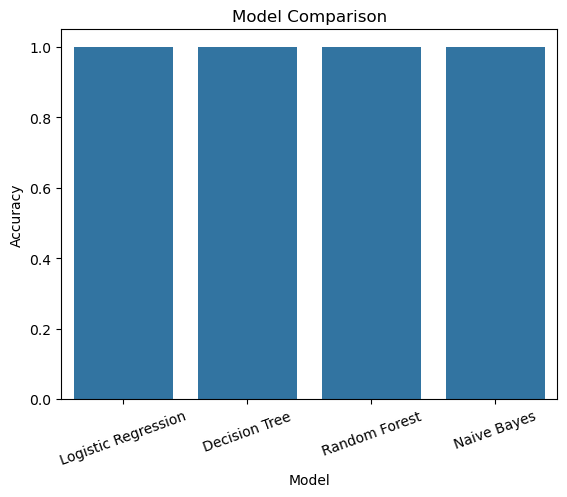

In [31]:
# Model Comparison Table


results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test_nb,y_pred_nb)
    ]
})

print(results)

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.xticks(rotation=20)

plt.title("Model Comparison")
plt.show()

**Accuracy (0.9995)**
The model correctly predicted the class for 99.95% of the 10,000 test samples, making exactly 5 total mistakes.

**Precision (1.00 for most classes, lower for 9 and 28)**
The model was correct 100% of the time it predicted a specific class, with exceptions for class 9 (90% correct due to false positives) and class 28 (0% correct, meaning its prediction for this class was wrong).

**Recall (1.00 for most classes, lower for 12 and 28)**
The model successfully found all actual instances for most classes. However, it missed 2 out of 11 samples for class 12 (82% found), and it completely missed the only available sample for class 28 (0% found).

**F1-Score (1.00 for most classes, 0.00 for class 28)**
The balance between precision and recall remains near-perfect across the dataset, except for class 12 (0.90) and class 28 (0.00), where the model completely failed to correctly identify the category.

**Support (ranging from 1 to 2,057)**
The dataset shows extreme class imbalance, where some categories contain thousands of examples (class 29 has 2,057) while others contain nearly none (class 28 has only 1).

In [37]:
# Hyperparameter Tuning (Random Forest)


param_grid = {
    'classifier__n_estimators':[100,200],
    'classifier__max_depth':[10,20,None],
    'classifier__min_samples_split':[2,5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best Accuracy:",
    grid_search.best_score_
)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Accuracy: 0.9991000018738282


**Best Parameters**
The hyperparameter tuning process determined that the optimal configuration for the model is to allow the tree to grow with no maximum depth (`max_depth: None`), require at least 2 samples to split an internal node (`min_samples_split: 2`), and use an ensemble of 200 individual trees (`n_estimators: 200`).

**Best Accuracy (0.9991000018738282)**
Using this exact combination of parameters during cross-validation, the model achieved a peak correct prediction rate of approximately 99.91%.

In [38]:
# Evaluate Tuned Model


best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00       635
           2       1.00      1.00      1.00      1896
           3       1.00      1.00      1.00       515
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00      1129
           6       1.00      1.00      1.00       280
           7       1.00      1.00      1.00       293
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        21
          11       1.00      0.82      0.90        11
          12       1.00      0.82      0.90        11
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00        28
          15       1.00      1.00      1.00       538
          16       1.00      1.00      1.00      1106
          19       1.00      0.97      0.99        68
          21       0.99    

**Accuracy (1.00)**
The model correctly predicted the class for 99.93% of the 10,000 test samples, which rounds to 1.00 on the summary line, making exactly 7 total mistakes.

**Precision (1.00 for almost all classes, 0.99 for class 21)**
The model was correct 100% of the time it predicted a specific class, with a slight exception for class 21 (99% correct), meaning it accidentally included an incorrect sample in that category.

**Recall (1.00 for most classes, lower for 11, 12, 19, 24)**
The model successfully found all actual instances for most classes. However, it missed 2 out of 11 samples for class 11 (82% found), 2 out of 11 samples for class 12 (82% found), 2 out of 68 samples for class 19 (97% found), and 1 out of 53 samples for class 24 (98% found).

**F1-Score (1.00 for most classes)**
The balance between precision and recall remains near-perfect across the dataset, with minor drops occurring in classes 11 (0.90), 12 (0.90), 19 (0.99), 21 (0.99), and 24 (0.99).

**Support (ranging from 1 to 2,057)**
The dataset shows extreme class imbalance, where some categories contain thousands of examples (class 29 has 2,057) while others contain nearly none (class 28 has 1).

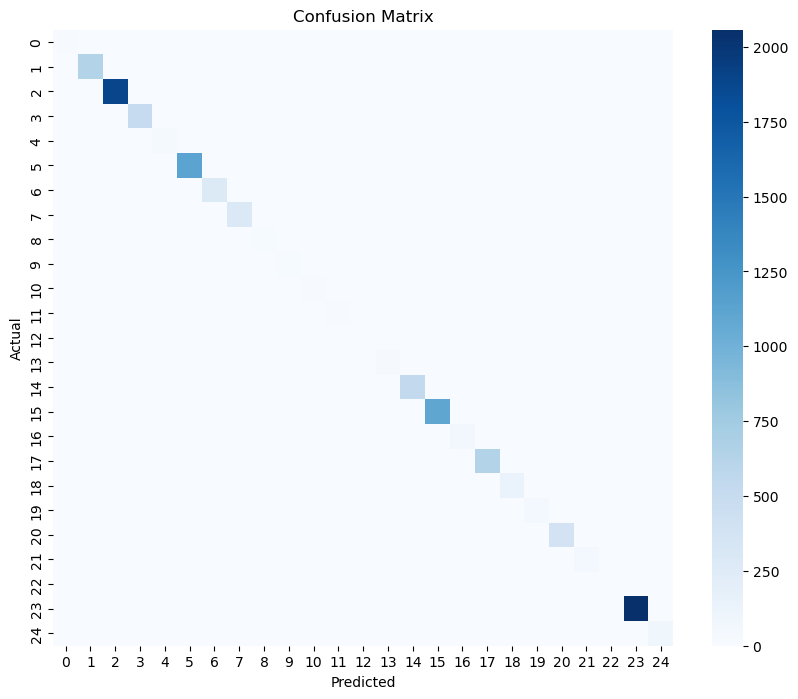

In [39]:
# Confusion Matrix


cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
# Save Final Model


import joblib

joblib.dump(
    best_model,
    "crime_prediction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
